<a href="https://colab.research.google.com/github/gamzedrn/Softito-Egitim-Calismalari/blob/main/Financial-data-analysis-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kütüphaneler ve Veri Yükleme

In [ ]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Algoritmalar (Kümeleme)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Boyut indirgeme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Değerlendirme Metrikleri
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')

Herşey hazır


## Veri Yükleme

In [ ]:
data = pd.read_csv('/Financials.csv')
df = data.copy()

print(f'Veri Seti Boyutu: {df.shape}')
print(f'Sütun Sayısı: {len(df.columns)}')
print(f'Satır Sayısı: {len(df)}')

Veri Seti Boyutu: (700, 16)
Sütun Sayısı: 16
Satır Sayısı: 700


## Keşifsel Veri Analizi (EDA)

In [ ]:
# Genel bilgi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [ ]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [ ]:
# İstatistiksel özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Month Number,700.0,7.90,3.377321,1.0,5.75,9.0,10.25,12.0
Year,700.0,2013.75,0.433322,2013.0,2013.75,2014.0,2014.00,2014.0


In [ ]:
# Eksik değerler
print('Eksik Değerler')
print('--' * 50)
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'Toplam eksik değer: {df.isnull().sum().sum()}')
print('--' * 50)

Eksik Değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
Toplam eksik değer: 0
----------------------------------------------------------------------------------------------------


## Veri Ön İşleme

In [ ]:
# Sütun adlarındaki boşlukları temizle
df.columns = df.columns.str.strip()
print("Sütunlar:", df.columns.tolist())
df.head(3)

Sütunlar: ['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014


In [ ]:
# Kategorik sütunları ayır
categorical_cols = ['Segment', 'Country', 'Product', 'Discount Band',
                    'Date', 'Month Name']

# Para birimi ve sayısal temizleme fonksiyonu
def clean_numeric(val):
    if isinstance(val, str):
        return val.replace('$', '').replace('%', '').replace(',', '').replace(' ', '').strip()
    return val

df_clean = df.copy()

# Sayıya çevrilmesi gereken sütunlar
numeric_target_cols = ['Units Sold', 'Manufacturing Price', 'Sale Price',
                        'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

for col in numeric_target_cols:
    df_clean[col] = df_clean[col].apply(clean_numeric)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


print(df_clean[numeric_target_cols].dtypes)
print(f"\nEksik değer (coerce sonrası): {df_clean[numeric_target_cols].isnull().sum().sum()}")
df_clean[numeric_target_cols].head(3)

Units Sold             float64
Manufacturing Price    float64
Sale Price             float64
Gross Sales            float64
Discounts              float64
Sales                  float64
COGS                   float64
Profit                 float64
dtype: object

Eksik değer (coerce sonrası): 116


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit
0,1618.5,3.0,20.0,32370.0,NaN,32370.0,16185.0,16185.0
1,1321.0,3.0,20.0,26420.0,NaN,26420.0,13210.0,13210.0
2,2178.0,3.0,15.0,32670.0,NaN,32670.0,21780.0,10890.0


In [ ]:
# Sadece sayısal sütunları al
numeric_cols = numeric_target_cols + ['Month Number', 'Year']
df_numeric = df_clean[numeric_cols]

print(f'Sayısal sütun sayısı: {df_numeric.shape[1]}')
print(df_numeric.describe().T.round(2))

Sayısal sütun sayısı: 10
                     count       mean        std      min       25%       50%  \
Units Sold           700.0    1608.29     867.43   200.00    905.00   1542.50   
Manufacturing Price  700.0      96.48     108.60     3.00      5.00     10.00   
Sale Price           700.0     118.43     136.78     7.00     12.00     20.00   
Gross Sales          700.0  182759.43  254262.28  1799.00  17391.75  37980.00   
Discounts            647.0   14227.59   23562.83    18.41   1061.00   3108.00   
Sales                700.0  169609.07  236726.35  1655.08  15928.00  35540.20   
COGS                 700.0  145475.21  203865.51   918.00   7490.00  22506.25   
Profit               637.0   27741.01   43059.33   285.60   3875.85  11106.10   
Month Number         700.0       7.90       3.38     1.00      5.75      9.00   
Year                 700.0    2013.75       0.43  2013.00   2013.75   2014.00   

                           75%        max  
Units Sold             2229.12     4492

In [ ]:
# Eksik değerleri ortalama ile doldur
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric),
    columns=df_numeric.columns
)

print(f'Toplam eksik değer (impute sonrası): {df_imputed.isnull().sum().sum()}')

Toplam eksik değer (impute sonrası): 0


In [ ]:
# Ölçekleme
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_imputed)
x_scaled = pd.DataFrame(x_scaled, columns=df_imputed.columns)

print('Ölçeklenmiş veri seti:')
x_scaled.head(3)

Ölçeklenmiş veri seti:


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
0,0.011774,-0.861342,-0.720150,-0.591897,8.035917e-17,-0.580152,-0.634647,-0.281554,-2.044501,0.57735
1,-0.331439,-0.861342,-0.720150,-0.615314,8.035917e-17,-0.605304,-0.649251,-0.354037,-2.044501,0.57735
2,0.657246,-0.861342,-0.756733,-0.590716,8.035917e-17,-0.578884,-0.607183,-0.410562,-0.562978,0.57735


## K-Means Kümeleme

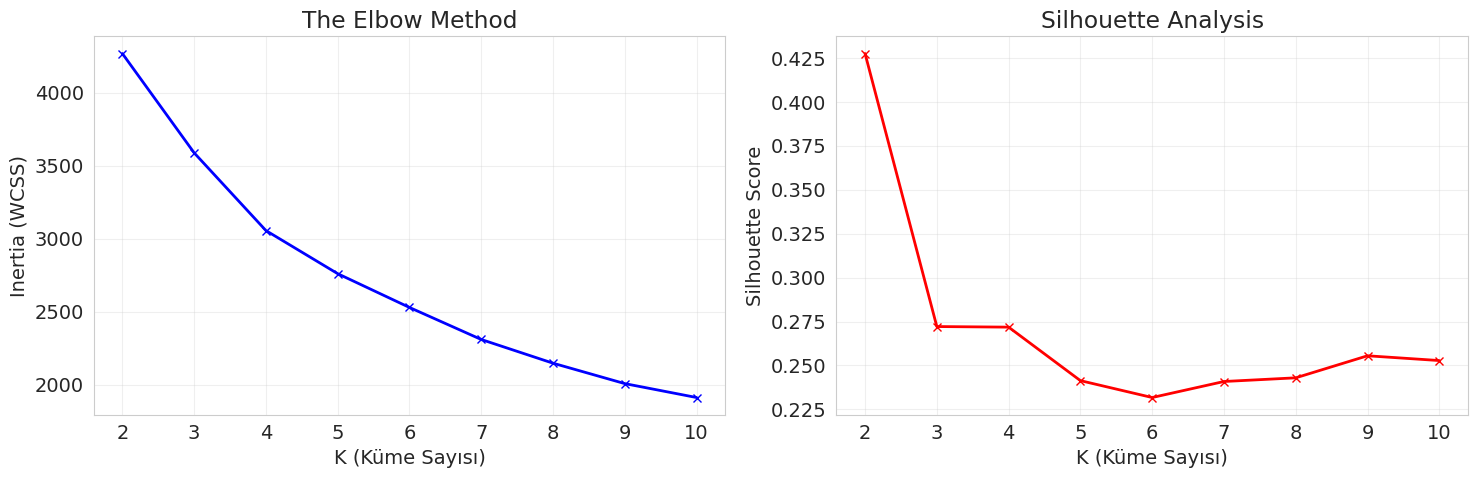

En iyi silhouette skoru: 0.4277
Optimum küme sayısı: 2


In [ ]:
# Elbow ve Silhouette ile optimal K belirleme
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertia, 'bx-', linewidth=2)
axes[0].set_xlabel('K (Küme Sayısı)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('The Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2)
axes[1].set_xlabel('K (Küme Sayısı)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum küme sayısı: {optimal_k}')

In [ ]:
# Elbow: Belirgin bir dirsek yok, eğri düzgün azalıyor → K=3 civarında hafif kırılma var
# Silhouette: K=2 açık ara en yüksek (0.425), sonra düşüyor

# Bu veri seti için K=2 matematiksel optimum ama anlamsal olarak K=3 daha yorumlanabilir olur

## K-Means Modeli — K=2 ve K=3 Karşılaştırması

In [ ]:
# Her iki K için de dene, karşılaştır
for k in [2, 3]:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(x_scaled)
    print(f'--- K={k} ---')
    print(f'Silhouette  : {silhouette_score(x_scaled, lbl):.4f}')
    print(f'Davies-Bouldin : {davies_bouldin_score(x_scaled, lbl):.4f}  (↓ iyi)')
    print(f'Calinski-Harabasz: {calinski_harabasz_score(x_scaled, lbl):.4f}  (↑ iyi)')
    print(f'Küme dağılımı:\n{pd.Series(lbl).value_counts().sort_index()}\n')

--- K=2 ---
Silhouette  : 0.4277
Davies-Bouldin : 1.0740  (↓ iyi)
Calinski-Harabasz: 447.0056  (↑ iyi)
Küme dağılımı:
0    548
1    152
Name: count, dtype: int64

--- K=3 ---
Silhouette  : 0.2722
Davies-Bouldin : 1.3148  (↓ iyi)
Calinski-Harabasz: 331.5617  (↑ iyi)
Küme dağılımı:
0    149
1    411
2    140
Name: count, dtype: int64



In [ ]:
# K=2 ile devam (silhouette'e göre en iyi)
optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

print(f'Seçilen K: {optimal_k}')
print(f'Silhouette Skoru : {silhouette_score(x_scaled, kmeans_labels):.4f}')
print(f'Davies Bouldin   : {davies_bouldin_score(x_scaled, kmeans_labels):.4f}')
print(f'Calinski Harabasz: {calinski_harabasz_score(x_scaled, kmeans_labels):.4f}')

Seçilen K: 2
Silhouette Skoru : 0.4277
Davies Bouldin   : 1.0740
Calinski Harabasz: 447.0056


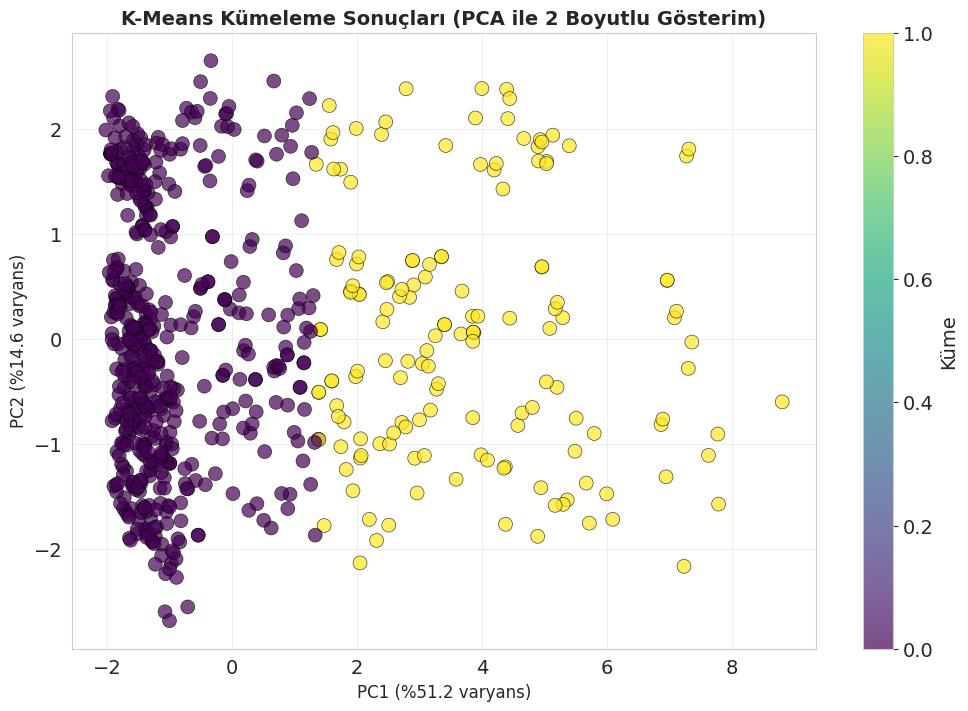

In [ ]:
# PCA ile görselleştirme
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=100, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('K-Means Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Küme profilleri
df_imputed['KMeans_Cluster'] = kmeans_labels
cluster_summary = df_imputed.groupby('KMeans_Cluster').mean().round(2)
print('K-Means Küme Profilleri:')
cluster_summary

K-Means Küme Profilleri:


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
KMeans_Cluster,,,,,,,,,,
0,1489.66,95.26,65.60,65978.21,5820.63,61273.99,52862.90,11937.90,7.94,2013.74
1,2036.02,100.87,308.88,603786.43,44536.89,560185.56,479366.97,84715.39,7.76,2013.79


## Hiyerarşik Kümeleme

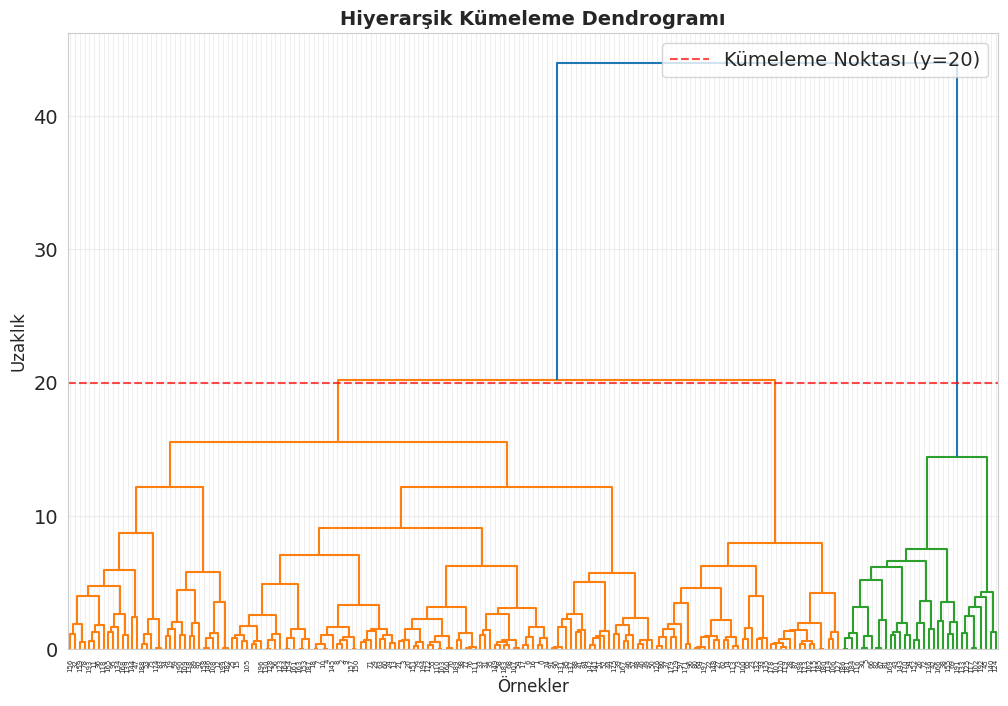

In [ ]:
# Dendrogram
plt.figure(figsize=(12, 8))
linked = linkage(x_scaled[:200], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarşik Kümeleme Dendrogramı', fontsize=14, fontweight='bold')
plt.xlabel('Örnekler', fontsize=12)
plt.ylabel('Uzaklık', fontsize=12)
plt.axhline(y=20, color='r', linestyle='--', alpha=0.7, label='Kümeleme Noktası (y=20)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# veri iki ana kökten beslenmiş

In [ ]:
# Agglomerative Clustering — K-Means ile aynı optimal_k kullan
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(x_scaled)

print('Hiyerarşik (Agglomerative) Kümeleme Sonuçları:')
print(f'Küme Sayısı     : {optimal_k}')
print(f'Bağlantı Yöntemi: ward')
print(f'Silhouette      : {silhouette_score(x_scaled, agg_labels):.4f}')
print(f'Davies Bouldin  : {davies_bouldin_score(x_scaled, agg_labels):.4f}  (↓ iyi)')
print(f'Calinski Harabasz: {calinski_harabasz_score(x_scaled, agg_labels):.4f}  (↑ iyi)')
print(f'\nKüme Dağılımı:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarşik (Agglomerative) Kümeleme Sonuçları:
Küme Sayısı     : 2
Bağlantı Yöntemi: ward
Silhouette      : 0.4481
Davies Bouldin  : 1.0009  (↓ iyi)
Calinski Harabasz: 410.1137  (↑ iyi)

Küme Dağılımı:
0    587
1    113
Name: count, dtype: int64


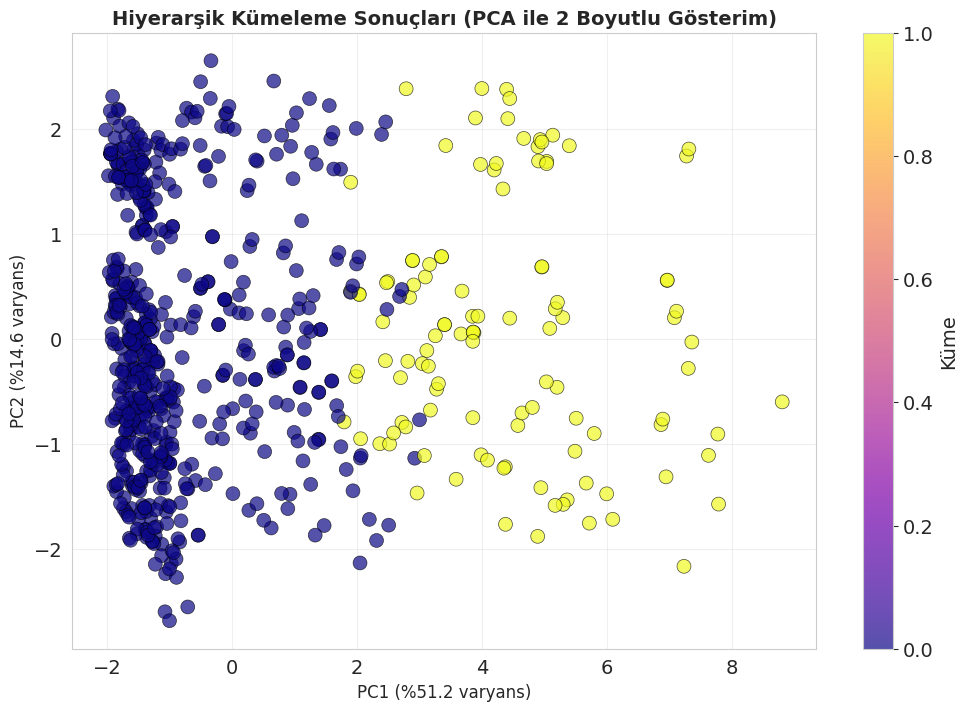

In [ ]:
# Görselleştirme
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=100, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('Hiyerarşik Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# K-Means vs Hiyerarşik — ne kadar örtüşüyor?
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(kmeans_labels, agg_labels)
print(f'Adjusted Rand Index (K-Means vs Hiyerarşik): {ari:.4f}')
print('(1.0 = tam örtüşme, 0 = rastgele)')

Adjusted Rand Index (K-Means vs Hiyerarşik): 0.7532
(1.0 = tam örtüşme, 0 = rastgele)


## DBSCAN

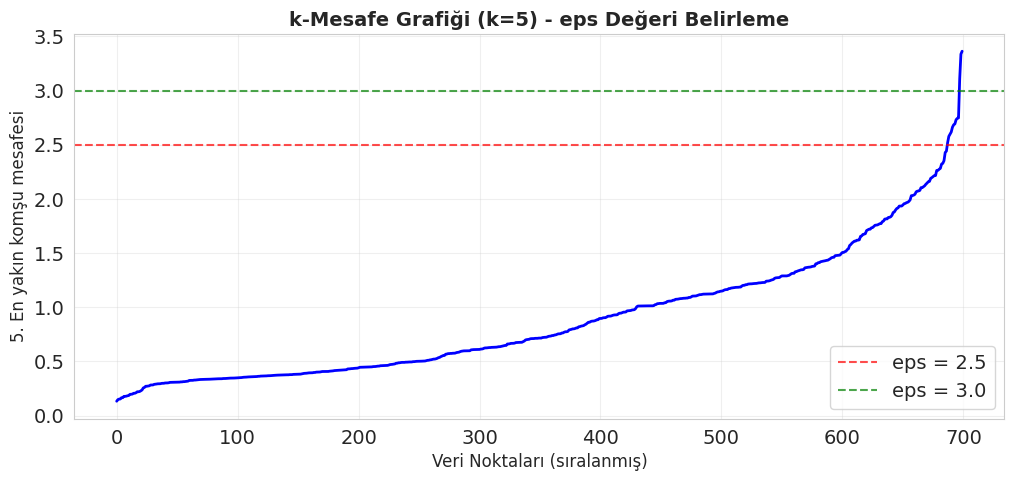

Mesafe istatistikleri:
Min : 0.133
%25 : 0.408
%50 : 0.716
%75 : 1.217
%90 : 1.761
Max : 3.364


In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafiği (k=5) - eps Değeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları (sıralanmış)', fontsize=12)
plt.ylabel('5. En yakın komşu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.axhline(y=3.0, color='g', linestyle='--', alpha=0.7, label='eps = 3.0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Dirsek noktasını yaklaşık bul
print(f'Mesafe istatistikleri:')
print(f'Min : {distances.min():.3f}')
print(f'%25 : {np.percentile(distances, 25):.3f}')
print(f'%50 : {np.percentile(distances, 50):.3f}')
print(f'%75 : {np.percentile(distances, 75):.3f}')
print(f'%90 : {np.percentile(distances, 90):.3f}')
print(f'Max : {distances.max():.3f}')

In [ ]:
# Farklı eps değerleri dene
for eps_val in [1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    lbl = db.fit_predict(x_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = list(lbl).count(-1)
    print(f'eps={eps_val} → Küme:{n_cl}  Gürültü:{n_noise} ({n_noise/len(lbl)*100:.1f}%)')

eps=1.5 → Küme:3  Gürültü:73 (10.4%)
eps=2.0 → Küme:2  Gürültü:19 (2.7%)
eps=2.5 → Küme:1  Gürültü:4 (0.6%)
eps=3.0 → Küme:1  Gürültü:0 (0.0%)


## DBSCAN — eps=2.0 ile Çalıştır

In [ ]:
# eps=2.0 seçimi
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kümeleme Sonuçları:')
print(f'Küme Sayısı   : {n_clusters_db}')
print(f'Gürültü Sayısı: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')

if n_clusters_db > 1:
    print(f'Silhouette      : {silhouette_score(x_scaled, dbscan_labels):.4f}')
    print(f'Davies Bouldin  : {davies_bouldin_score(x_scaled, dbscan_labels):.4f}  (↓ iyi)')
    print(f'Calinski Harabasz: {calinski_harabasz_score(x_scaled, dbscan_labels):.4f}  (↑ iyi)')

print(f'\nKüme Dağılımı (-1 = gürültü):')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kümeleme Sonuçları:
Küme Sayısı   : 2
Gürültü Sayısı: 19 (2.7%)
Silhouette      : 0.1877
Davies Bouldin  : 1.5923  (↓ iyi)
Calinski Harabasz: 109.5542  (↑ iyi)

Küme Dağılımı (-1 = gürültü):
-1     19
 0    509
 1    172
Name: count, dtype: int64


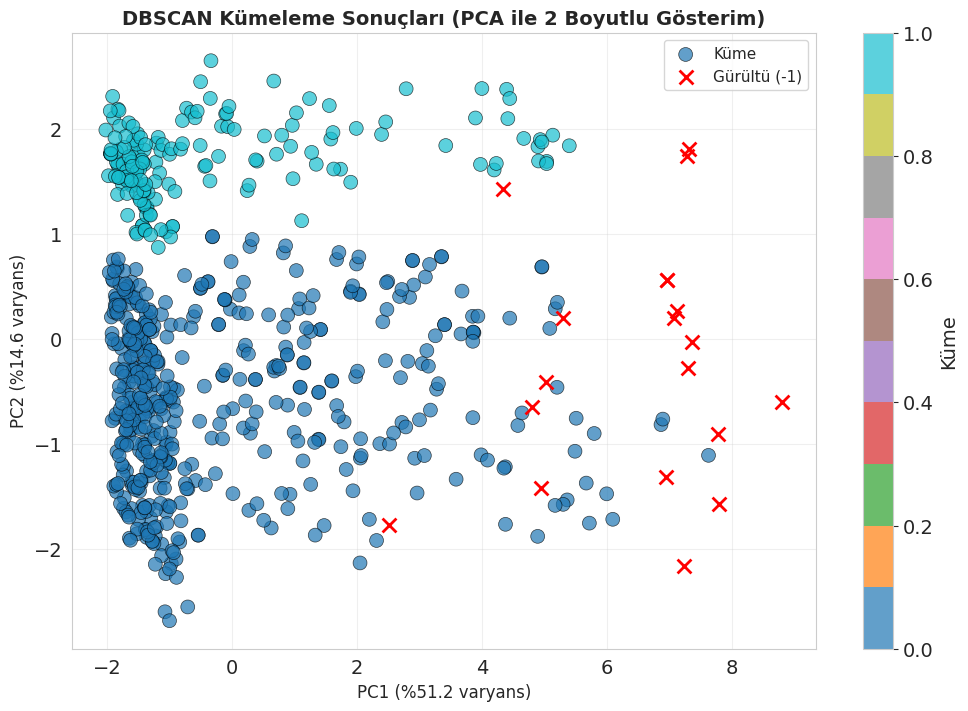

In [ ]:
# Görselleştirme — gürültü noktaları farklı işaretle
plt.figure(figsize=(12, 8))

# Gürültü ve küme noktalarını ayır
noise_mask = dbscan_labels == -1
cluster_mask = dbscan_labels != -1

# Önce küme noktaları
scatter = plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                      c=dbscan_labels[cluster_mask], cmap='tab10',
                      alpha=0.7, s=100, edgecolors='k', linewidth=0.5, label='Küme')

# Sonra gürültü noktaları (kırmızı X)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='red', marker='x', s=100, linewidths=2, label='Gürültü (-1)')

plt.colorbar(scatter, label='Küme')
plt.title('DBSCAN Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Gaussian Mixture Model

In [ ]:
# GMM
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full',
                      max_iter=200, random_state=42)
gmm_labels = gmm.fit_predict(x_scaled)
gmm_probs = gmm.predict_proba(x_scaled)

print('GMM Kümeleme Sonuçları:')
print(f'Küme Sayısı       : {optimal_k}')
print(f'Silhouette        : {silhouette_score(x_scaled, gmm_labels):.4f}')
print(f'Davies Bouldin    : {davies_bouldin_score(x_scaled, gmm_labels):.4f}  (↓ iyi)')
print(f'Calinski Harabasz : {calinski_harabasz_score(x_scaled, gmm_labels):.4f}  (↑ iyi)')
print(f'AIC               : {gmm.aic(x_scaled):.2f}  (↓ iyi)')
print(f'BIC               : {gmm.bic(x_scaled):.2f}  (↓ iyi)')
print(f'\nKüme Dağılımı:')
print(pd.Series(gmm_labels).value_counts().sort_index())

# GMM'e özgü: olasılık güven analizi
print(f'\nOrtalama atama güveni: {gmm_probs.max(axis=1).mean():.4f}')
print(f'Düşük güvenli (<0.7) nokta sayısı: {(gmm_probs.max(axis=1) < 0.7).sum()}')

GMM Kümeleme Sonuçları:
Küme Sayısı       : 2
Silhouette        : 0.2844
Davies Bouldin    : 1.4248  (↓ iyi)
Calinski Harabasz : 306.1274  (↑ iyi)
AIC               : -4072.48  (↓ iyi)
BIC               : -3476.29  (↓ iyi)

Küme Dağılımı:
0    400
1    300
Name: count, dtype: int64

Ortalama atama güveni: 1.0000
Düşük güvenli (<0.7) nokta sayısı: 0


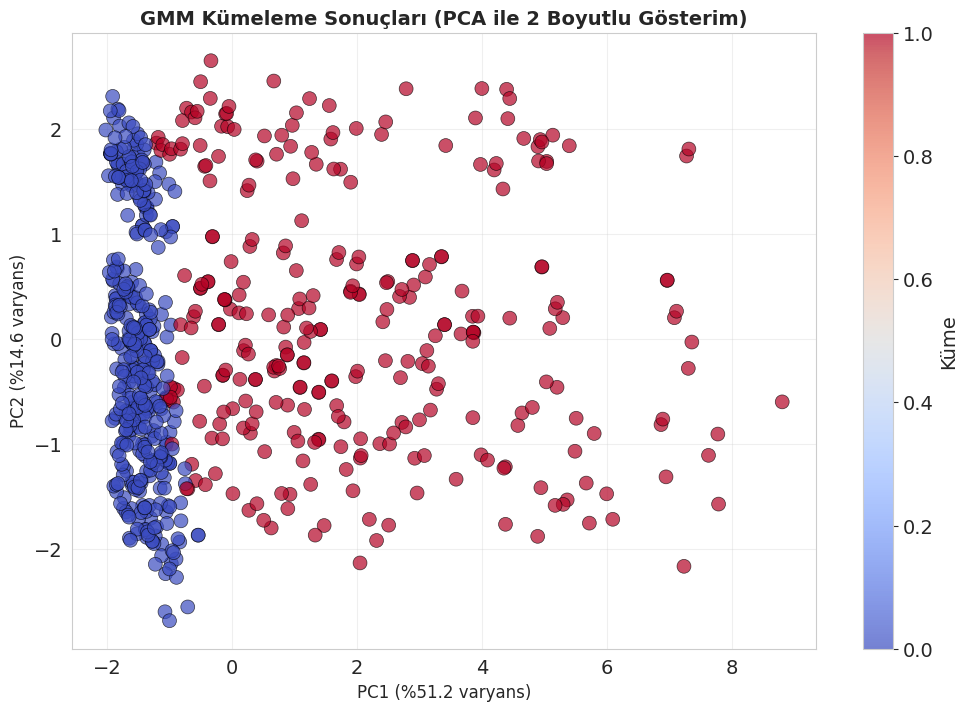

In [ ]:
# Görselleştirme
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm',
                      alpha=0.7, s=100, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('GMM Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

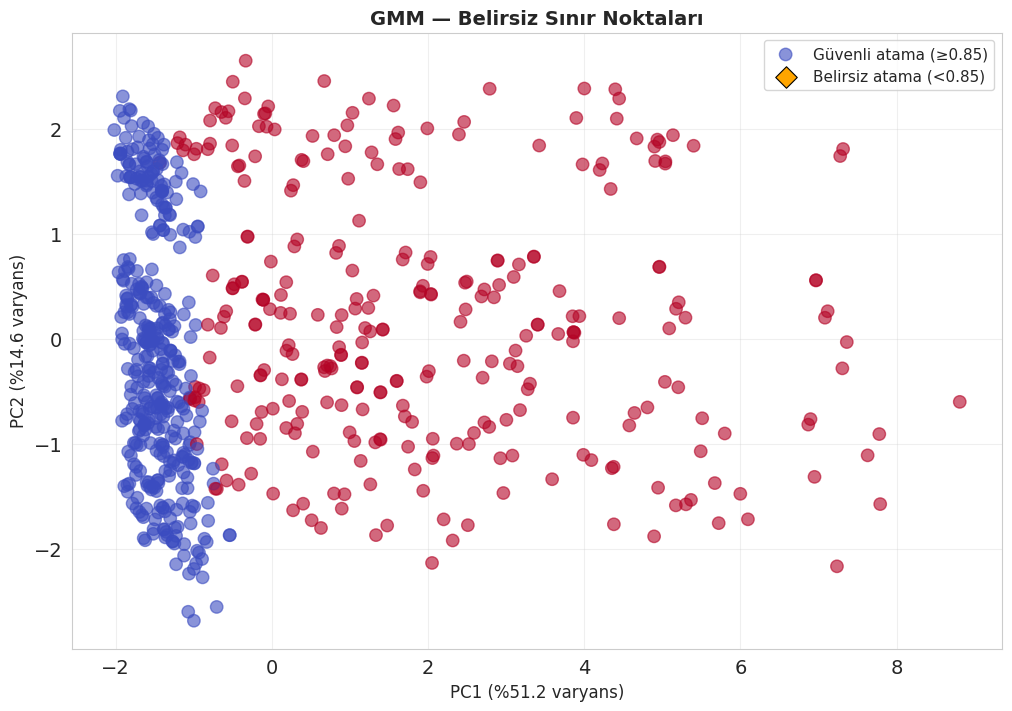

In [ ]:
# GMM'e özgü: belirsiz sınır noktalarını göster
max_probs = gmm_probs.max(axis=1)
uncertain_mask = max_probs < 0.85

plt.figure(figsize=(12, 8))
plt.scatter(X_pca[~uncertain_mask, 0], X_pca[~uncertain_mask, 1],
            c=gmm_labels[~uncertain_mask], cmap='coolwarm',
            alpha=0.6, s=80, label='Güvenli atama (≥0.85)')
plt.scatter(X_pca[uncertain_mask, 0], X_pca[uncertain_mask, 1],
            c='orange', marker='D', s=120, edgecolors='k',
            linewidth=0.8, label='Belirsiz atama (<0.85)', zorder=5)
plt.title('GMM — Belirsiz Sınır Noktaları', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()